# DOG vs CAT Classification using Transfer Learning

 We will be using the MobileNet modelthrough this project.

The dataset used is "Dogs vs. Cats" dataset from Kaggle:
 https://www.kaggle.com/competitions/dogs-vs-cats

In [1]:
!pip install kaggle

In [2]:
# configuring the path of keagle.json file
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

### Importing the DOG vs CAT dataset from kaggle

In [3]:
! kaggle competitions download -c dogs-vs-cats

 90% 730M/812M [00:00<00:00, 1.32GB/s]
100% 812M/812M [00:00<00:00, 1.37GB/s]


In [4]:
# Extracting the file
from zipfile import ZipFile
dataset='/content/dogs-vs-cats.zip'

with ZipFile(dataset,'r') as zip:
   zip.extractall()


In [5]:
# Extracting the file
from zipfile import ZipFile
dataset='/content/train.zip'

with ZipFile(dataset,'r') as zip:
   zip.extractall()

In [6]:
# Extracting the file
from zipfile import ZipFile
dataset='/content/test1.zip'

with ZipFile(dataset,'r') as zip:
   zip.extractall()

In [7]:
import os
print(os.listdir('/content/train'))

['cat.4756.jpg', 'dog.12254.jpg', 'cat.10505.jpg', 'dog.3344.jpg', 'dog.6892.jpg', 'cat.9642.jpg', 'cat.862.jpg', 'cat.12247.jpg', 'cat.10334.jpg', 'dog.4515.jpg', 'cat.2322.jpg', 'cat.11847.jpg', 'cat.3630.jpg', 'cat.6807.jpg', 'cat.7632.jpg', 'dog.5112.jpg', 'cat.10036.jpg', 'cat.3419.jpg', 'dog.6429.jpg', 'cat.3227.jpg', 'cat.7493.jpg', 'cat.1611.jpg', 'cat.9198.jpg', 'cat.1140.jpg', 'dog.2922.jpg', 'cat.6747.jpg', 'cat.10650.jpg', 'cat.1296.jpg', 'cat.11558.jpg', 'dog.7945.jpg', 'cat.10918.jpg', 'dog.9640.jpg', 'dog.887.jpg', 'cat.8586.jpg', 'dog.10933.jpg', 'cat.9502.jpg', 'dog.9765.jpg', 'dog.10011.jpg', 'cat.9153.jpg', 'dog.4237.jpg', 'dog.12102.jpg', 'dog.3583.jpg', 'dog.3146.jpg', 'dog.9455.jpg', 'cat.5271.jpg', 'dog.2475.jpg', 'dog.6612.jpg', 'cat.11515.jpg', 'dog.3913.jpg', 'cat.8219.jpg', 'cat.2562.jpg', 'cat.11722.jpg', 'dog.3775.jpg', 'dog.10878.jpg', 'dog.292.jpg', 'dog.1344.jpg', 'dog.1702.jpg', 'dog.9276.jpg', 'dog.6265.jpg', 'dog.5397.jpg', 'cat.8779.jpg', 'dog.7115.j

### Importing dependencies

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split



### Displaying dog and cat images

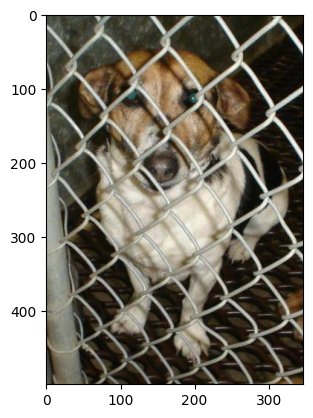

In [10]:
# displaying a dog image
img=mpimg.imread('/content/train/dog.1245.jpg')
imgplot=plt.imshow(img)
plt.show()

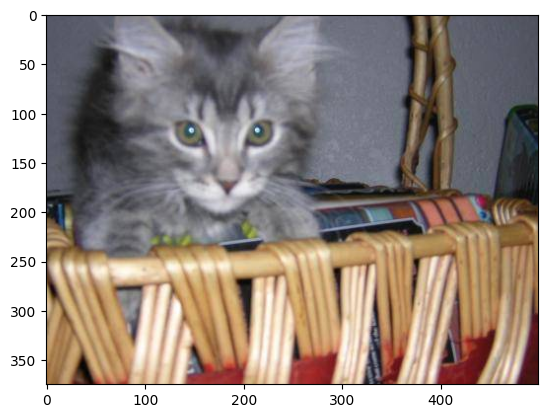

In [11]:
# Displaying a cat image
img=mpimg.imread('/content/train/cat.12299.jpg')
imgplot=plt.imshow(img)
plt.show()

### Resizing all the images
The MobileNetV2 model only accepts 224x224 images
* *The dataset contains 12.5k dog images and the same amount of cat images aswell,we're not ,gonna use them all in our training procedure* *

In [23]:
# Creating a new directory that will contain the resized images:
os.mkdir('/content/resized images')

In [24]:
original_folder='/content/train/'
resized_folder='/content/resized images/'

for i in range(2000):

  file_name=os.listdir(original_folder)[i]
  img_path=original_folder+file_name
  img=Image.open(img_path)
  img=img.resize((224,224))
  img=img.convert('RGB')
  new_img_path=resized_folder+file_name
  img.save(new_img_path)

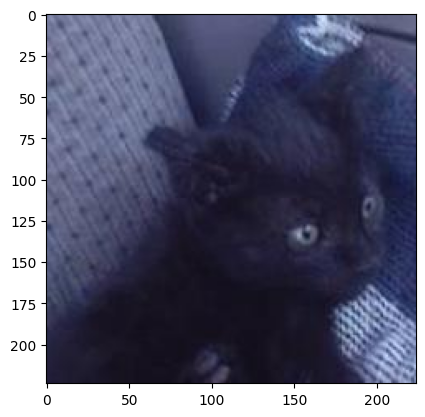

In [27]:
img=mpimg.imread('/content/resized images/cat.10065.jpg')
imgplot=plt.imshow(img)
plt.show()

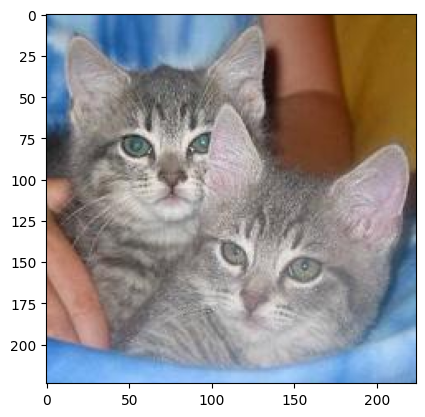

In [21]:
img=mpimg.imread('/content/resized images/cat.10021.jpg')
imgplot=plt.imshow(img)
plt.show()

### Creating labels for the images

Cat --> 0
Dog --> 1

In [28]:
import os
labels=[]
filenames=os.listdir('/content/resized images/')
for i in range(2000):
   file_name=filenames[i]
   name=file_name[0:3]
   if name =='cat':
    labels.append(0)
   else:
    labels.append(1)





In [29]:
print(labels[0:10])

[0, 1, 0, 1, 1, 0, 0, 0, 0, 1]


In [30]:
# counting the number of dog and cat images
dog_count=0
cat_count=0


for i in range(2000):
  if labels[i]==0:
    cat_count+=1
  else:
    dog_count+=1
print(f'dog count: {dog_count}\ncat count: {cat_count}')

dog count: 995
cat count: 1005


### Converting images to numpy arrays

In [34]:
!pip install opencv-python
import cv2
import glob
img_directory='/content/resized images/'
img_extensions=['png','jpg']
files=[]
[files.extend(glob.glob(img_directory+'*.'+e)) for e in img_extensions]
dog_cat_images=np.asarray([cv2.imread(file) for file in files])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 21.4 MB/s eta 0:00:00


In [35]:
type(dog_cat_images)

numpy.ndarray

In [36]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [37]:
X=dog_cat_images
Y=np.asarray(labels)

### Splitting the data

In [38]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [39]:
print(X_train.shape,X_test.shape,X.shape)

(1600, 224, 224, 3) (400, 224, 224, 3) (2000, 224, 224, 3)


1600 training data points(images)
400 testing data points(images)

In [40]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [41]:
X_train_scaled

array([[[[0.88627451, 0.95294118, 0.9372549 ],
         [0.90196078, 0.96862745, 0.95294118],
         [0.88235294, 0.95294118, 0.94901961],
         ...,
         [0.99215686, 1.        , 0.97647059],
         [1.        , 1.        , 0.97647059],
         [0.97647059, 0.98823529, 0.95294118]],

        [[0.86666667, 0.93333333, 0.91764706],
         [0.87843137, 0.94509804, 0.93333333],
         [0.85098039, 0.92156863, 0.91764706],
         ...,
         [0.97647059, 0.99607843, 0.96078431],
         [0.99215686, 1.        , 0.96862745],
         [0.96470588, 0.97647059, 0.94117647]],

        [[0.85882353, 0.9254902 , 0.91372549],
         [0.85882353, 0.9254902 , 0.91372549],
         [0.83137255, 0.90196078, 0.89803922],
         ...,
         [0.97254902, 0.99215686, 0.95686275],
         [0.98431373, 0.99215686, 0.96862745],
         [0.96470588, 0.97254902, 0.94901961]],

        ...,

        [[0.83921569, 0.88235294, 0.91372549],
         [0.83137255, 0.88627451, 0.90980392]

### Building the Neural Network

In [44]:
!pip install tensorflow


  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 742.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 1.9 MB/s eta 0:00:00


In [46]:
!pip install -- tensorflow_hub

  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)


In [47]:
import tensorflow as tf
import tensorflow_hub as hub

mobilenet_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

# Load TF-Hub SavedModel directly (NOT KerasLayer)
mobilenet = hub.load(mobilenet_model)

# Wrap it inside a Lambda layer
def mobilenet_fn(images):
    return mobilenet(images)

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.layers.Lambda(mobilenet_fn)(inputs)
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562 (10.01 KB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
model.fit(X_train_scaled,Y_train,epochs=10)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 386ms/step - accuracy: 0.9976 - loss: 0.0209
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.9961 - loss: 0.0197
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.9996 - loss: 0.0130
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.9992 - loss: 0.0100
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - accuracy: 0.9993 - loss: 0.0108
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.9992 - loss: 0.0082
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - accuracy: 0.9999 - loss: 0.0068
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - accuracy: 1.0000 - loss: 0.0075
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 1.0000 - loss: 0.0057
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - accuracy: 1.0000 - loss: 0.0053


In [54]:
score,acc=model.evaluate(X_test,Y_test)
print('score:',score)
print('accuracy:',acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.4802 - loss: 1.3574
score: 1.320509910583496
accuracy: 0.512499988079071


In [58]:
from google.colab.patches import cv2_imshow
import cv2

Path of the image to be predicted: /content//test1/10007.jpg
✔ Image loaded successfully.


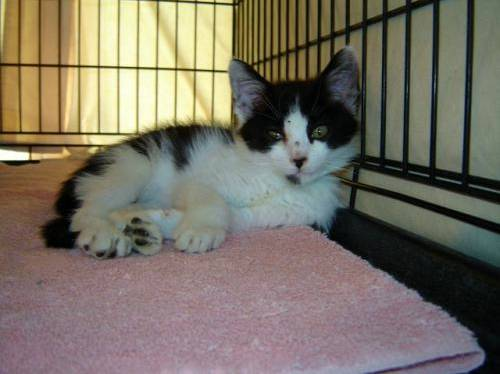

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.9970837  0.00291622]]
0
The image represents a Cat


In [84]:
import cv2
from google.colab.patches import cv2_imshow

input_image_path = input('Path of the image to be predicted: ')

# Read image
input_image = cv2.imread(input_image_path)

if input_image is None:
    print("❌ ERROR: Image not found. Check the path.")
else:
    print("✔ Image loaded successfully.")
    cv2_imshow(input_image)


input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')